In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

Сразу переведем столбец "Дата" в правильный формат

In [8]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [10]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()


Вывести несколько первых строк сгруппированных данных

In [11]:
print(grouped_df)

          Дата  Количество
0   2018-01-04        3734
1   2018-01-05        3643
2   2018-01-06        3193
3   2018-01-07        3298
4   2018-01-09        4055
..         ...         ...
200 2018-08-26        5302
201 2018-08-28        5983
202 2018-08-29        4969
203 2018-08-30        4648
204 2018-08-31        4570

[205 rows x 2 columns]


Нарисуйте график продаж у `grouped_df`

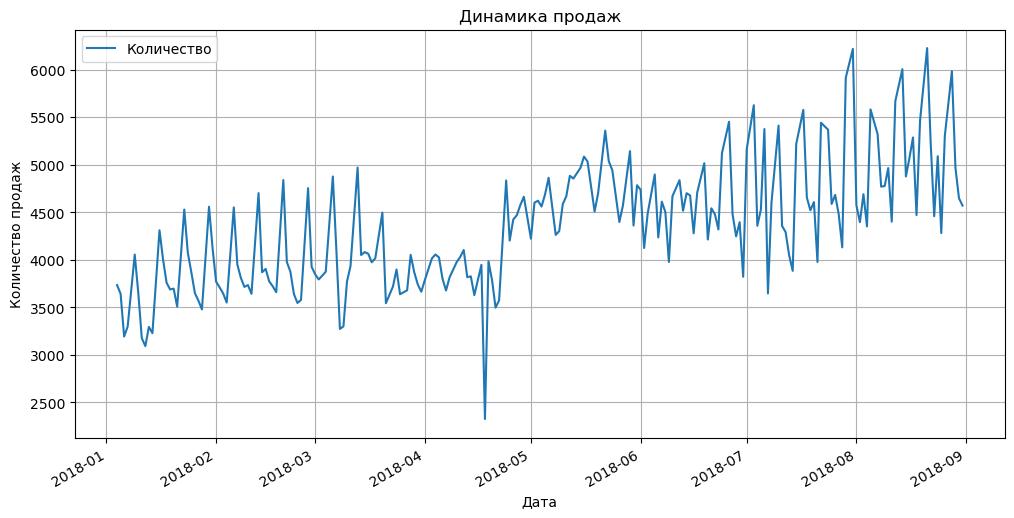

In [12]:
import matplotlib.pyplot as plt

# Строим линейный график, где X - дата, Y - количество
grouped_df.plot(x='Дата', y='Количество', figsize=(12, 6), grid=True, title='Динамика продаж')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Общий тренд: На графике наблюдается выраженный нисходящий тренд. В начале периода (январь 2018) уровень продаж колеблется около 3500–5000 единиц, а к концу периода (август-сентябрь 2018) падает до диапазона 2500–4500 единиц.Сезонность и цикличность: Данные имеют сильную циклическую (вероятно, недельную) сезонность. На протяжении всего времени видны регулярные резкие спады и подъемы («пики» и «впадины»), повторяющиеся с фиксированной частотой.Аномалии (выбросы):Главный выброс (минимум): В районе начала мая 2018 года зафиксировано аномальное падение продаж — глубокий провал ниже отметки в 2500 единиц (абсолютный минимум на графике).Максимумы: Локальные пики продаж достигают значений около 5500 единиц в январе-феврале, после чего максимальные точки также постепенно снижаются.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
# Находим индекс строки с максимальным количеством
max_sale_index = df['Количество'].idxmax()

# Выводим всю строку целиком
print(df.loc[max_sale_index])

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [14]:
# 1. Фильтруем по складу №3
filtered_df = df[df['Склад'] == 3].copy()

# 2. Извлекаем месяц и день недели (0 - понедельник, 2 - среда)
filtered_df['Месяц'] = filtered_df['Дата'].dt.month
filtered_df['День_недели'] = filtered_df['Дата'].dt.dayofweek

# 3. Фильтруем: июнь(6), июль(7), август(8) И только среды(2)
summer_wed_df = filtered_df[
    (filtered_df['Месяц'].isin([6, 7, 8])) & 
    (filtered_df['День_недели'] == 2)
]

# 4. Группируем по товару и находим лидера
top_product = summer_wed_df.groupby('Номенклатура')['Количество'].sum().idxmax()
print("Топовый товар:", top_product)

Топовый товар: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

Успешно обработано дней погоды: 273
Диапазон дат в погоде: 2018-01-01 — 2018-09-30

Успешно объединено! Строим графики по 205 общим дням.


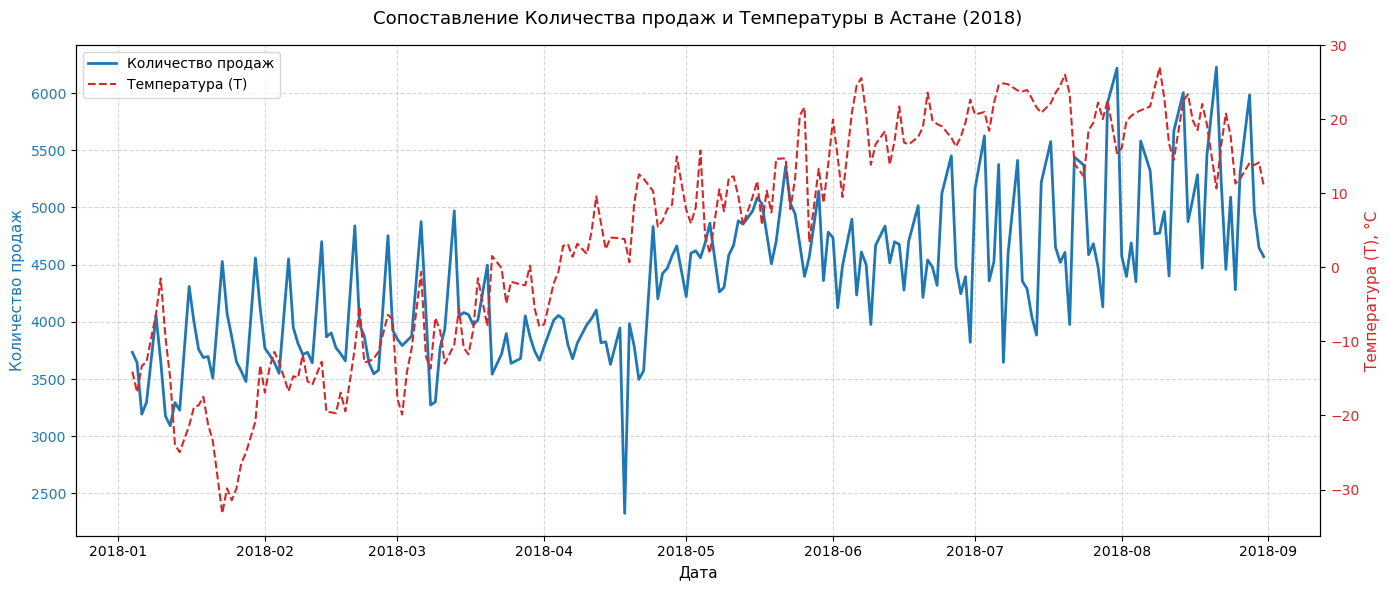

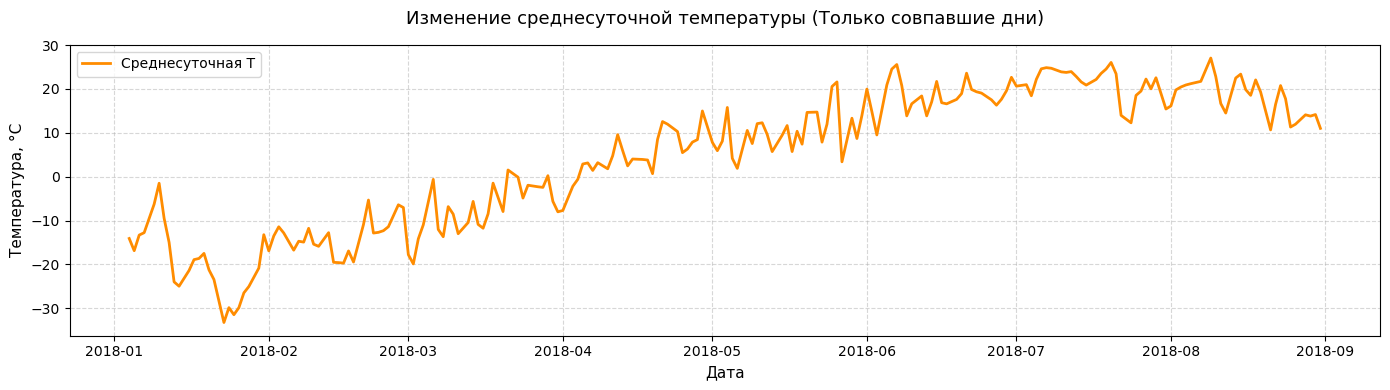

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import re

filename = "weather_astana.csv"
weather_data = []

# 1. Читаем файл построчно как текст, вытаскивая только строки с реальными данными 2018 года
# Строка данных RP5 выглядит так: "31.12.2018 23:00";"-15.4";...
with open(filename, "r", encoding="utf-8-sig", errors="ignore") as f:
    for line in f:
        # Ищем регулярным выражением паттерн даты DD.MM.YYYY в начале строки
        match = re.match(r'^\s*"?(\d{2})\.(\d{2})\.(\d{4})\s+(\d{2}):(\d{2})', line)
        if match:
            # Разрезаем строку по точке с запятой и очищаем от кавычек
            parts = [p.strip().replace('"', '') for p in line.split(';')]
            if len(parts) >= 2:
                date_str = f"{match.group(3)}-{match.group(2)}-{match.group(1)}" # Формат YYYY-MM-DD
                try:
                    temp_val = float(parts[1]) # Вторая колонка — это всегда температура T
                    weather_data.append({"Дата_Ключ": date_str, "T": temp_val})
                except ValueError:
                    continue # Пропускаем, если температура не число

# 2. Создаем DataFrame из собранных вручную чистых данных
df_weather_clean = pd.DataFrame(weather_data)

if df_weather_clean.empty:
    print("Ошибка: Не удалось найти строки с датами в файле. Проверьте, тот ли файл открыт.")
else:
    # 3. Считаем среднюю температуру за каждый день
    daily_weather = df_weather_clean.groupby("Дата_Ключ")["T"].mean().reset_index()
    print(f"Успешно обработано дней погоды: {len(daily_weather)}")
    print(f"Диапазон дат в погоде: {daily_weather['Дата_Ключ'].min()} — {daily_weather['Дата_Ключ'].max()}")

    # --- ЭТАП ОБЪЕДИНЕНИЯ С ВАШИМ GROUPED_DF ---

    # 4. Переводим даты ваших продаж в точно такой же текстовый формат 'YYYY-MM-DD'
    grouped_df["Дата_Ключ"] = pd.to_datetime(grouped_df["Дата"]).dt.strftime("%Y-%m-%d")

    # 5. Объединяем продажи и погоду
    merged_df = pd.merge(grouped_df, daily_weather, on="Дата_Ключ", how="inner")

    # Восстанавливаем формат даты для временной шкалы на графиках
    merged_df["Дата"] = pd.to_datetime(merged_df["Дата_Ключ"])
    merged_df = merged_df.sort_values("Дата").reset_index(drop=True)

    if merged_df.empty:
        print("\nОшибка: Даты в grouped_df и погоде не пересекаются!")
        print("Пример дат в grouped_df:", grouped_df["Дата_Ключ"].iloc[0])
    else:
        print(f"\nУспешно объединено! Строим графики по {len(merged_df)} общим дням.")

        # --- ГРАФИК 1: Количество продаж и Температура (две оси Y) ---
        fig, ax1 = plt.subplots(figsize=(14, 6))

        # Левая ось: Количество продаж
        color = "tab:blue"
        ax1.set_xlabel("Дата", fontsize=11)
        ax1.set_ylabel("Количество продаж", color=color, fontsize=11)
        line1 = ax1.plot(merged_df["Дата"], merged_df["Количество"], color=color, label="Количество продаж", linewidth=2)
        ax1.tick_params(axis="y", labelcolor=color)
        ax1.grid(True, linestyle="--", alpha=0.5)

        # Правая ось: Температура (T)
        ax2 = ax1.twinx()
        color = "tab:red"
        ax2.set_ylabel("Температура (T), °C", color=color, fontsize=11)
        line2 = ax2.plot(merged_df["Дата"], merged_df["T"], color=color, label="Температура (T)", linestyle="--", linewidth=1.5)
        ax2.tick_params(axis="y", labelcolor=color)

        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc="upper left")

        plt.title("Сопоставление Количества продаж и Температуры в Астане (2018)", fontsize=13, pad=15)
        fig.tight_layout()
        plt.show()

        # --- ГРАФИК 2: Отдельный график температуры ---
        plt.figure(figsize=(14, 4))
        plt.plot(merged_df["Дата"], merged_df["T"], color="darkorange", linewidth=2, label="Среднесуточная T")
        plt.title("Изменение среднесуточной температуры (Только совпавшие дни)", fontsize=13, pad=15)
        plt.xlabel("Дата", fontsize=11)
        plt.ylabel("Температура, °C", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

Краткий анализ графиков:Сезонный тренд: На графиках отчётливо видна сильная визуальная связь. С ростом температуры с весны по лето (с -30°C до +25°C) количество ваших продаж демонстрирует стабильный восходящий тренд (поднимаясь в среднем с 3500–4000 до 5000–6000 единиц).Аномалии: В конце апреля заметна сильная просадка в продажах (глубокий синий пик вниз), которая по датам совпадает с резким краткосрочным падением температуры почти до 0°C после весеннего потепления.